In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [80]:
df = pd.read_csv('data_science_job.csv')

In [81]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [82]:
(df.isnull().mean() )* 100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [83]:
df.shape

(19158, 13)

In [84]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [85]:
df[cols]

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
3,0.789,NaN,Graduate,0.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0
...,...,...,...,...,...
19153,0.878,no_enrollment,Graduate,14.0,42.0
19154,0.920,no_enrollment,Graduate,14.0,52.0
19155,0.920,no_enrollment,Graduate,20.0,44.0
19156,0.802,no_enrollment,High School,0.0,97.0


In [86]:
len(df[cols].dropna() ) / len(df)

0.8968577095730244

In [87]:
new_df = df[cols].dropna()

new_df.shape , df.shape

((17182, 5), (19158, 13))

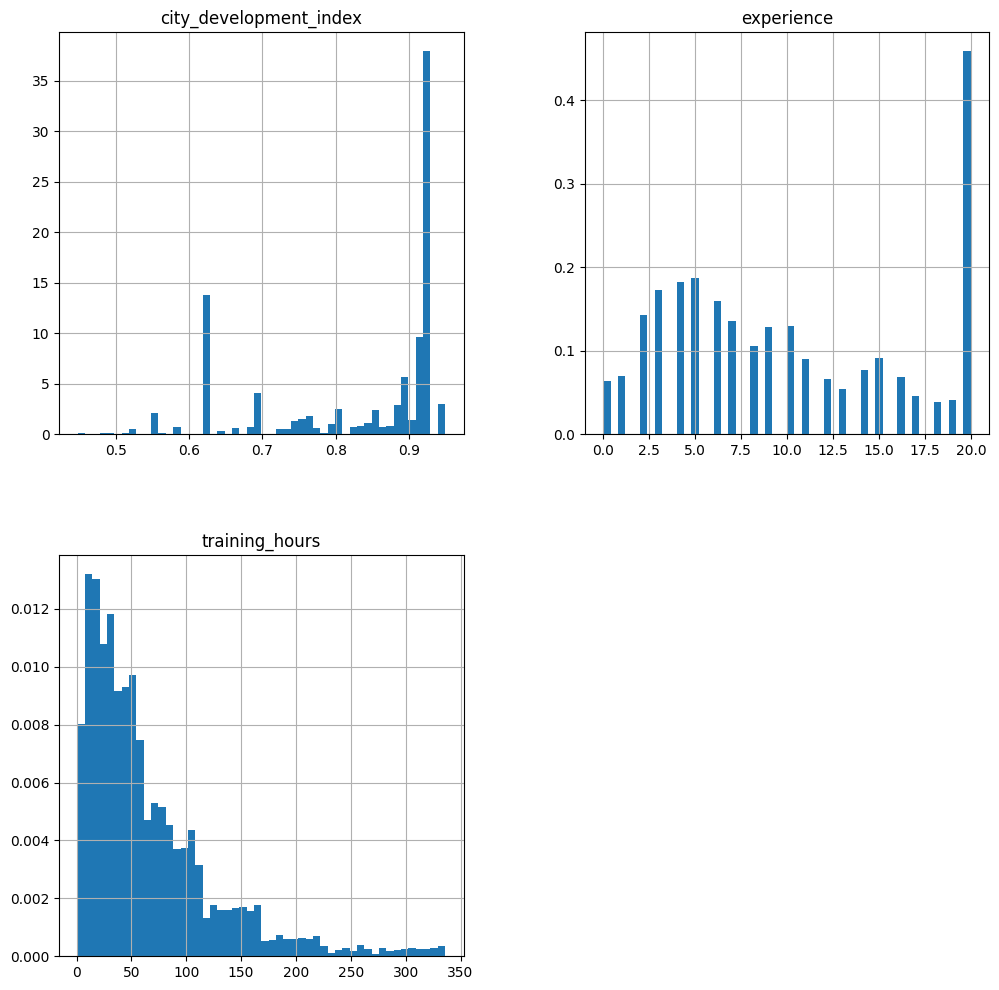

In [88]:
new_df.hist(bins=50 , density=True , figsize=(12,12))
plt.show()

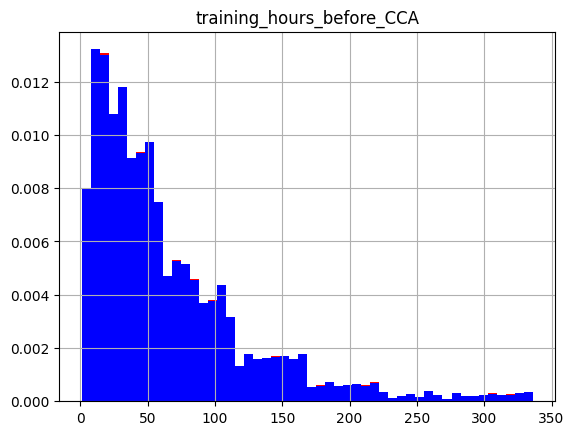

In [89]:
fig = plt.figure()
ax = fig.add_subplot(111)
# original data
df['training_hours'].hist(bins=50 , color='red', density=True , ax = ax)
plt.title('training_hours_before_CCA')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50 , color='Blue', density=True, ax=ax)
# both graph are on ech other shows  data miss completly at random 
plt.show()

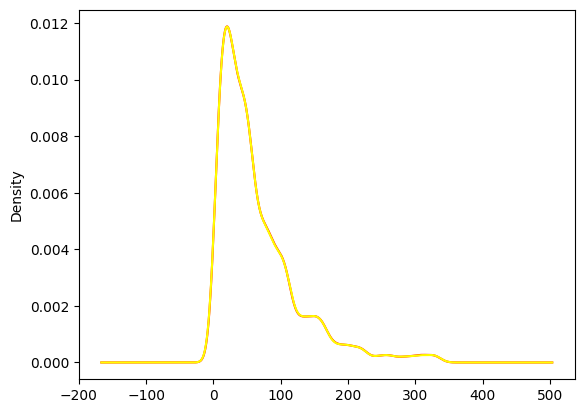

In [90]:
fig = plt.figure()   # both graph are on ech other shows  data miss completly at random 
ax = fig.add_subplot()

df['training_hours'].plot.density(color='red')

new_df['training_hours'].plot.density(color = 'yellow')
plt.show()

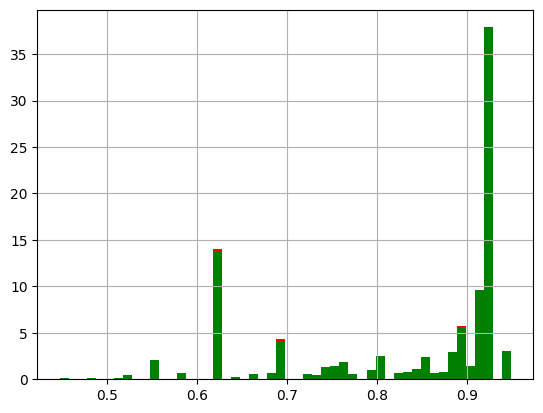

In [91]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['city_development_index'].hist(bins=50 , density = True , ax = ax , color = 'red')

new_df['city_development_index'].hist(bins=50 , density = True , ax = ax , color = 'green')

plt.show()

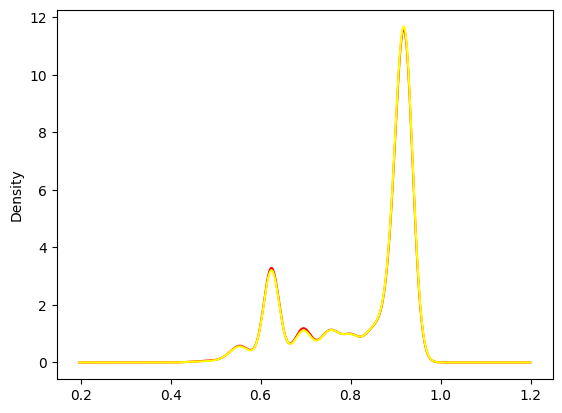

In [92]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['city_development_index'].plot.density(color='red')

new_df['city_development_index'].plot.density(color='yellow')

plt.show()

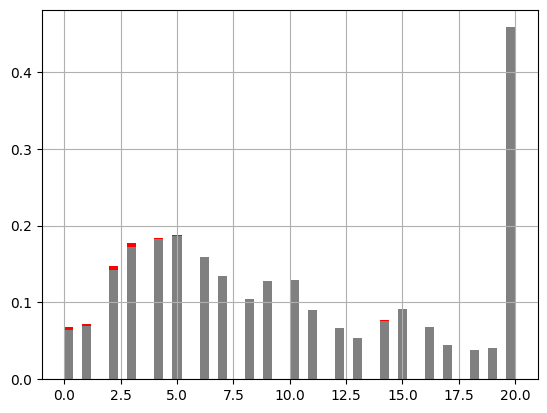

In [93]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['experience'].hist(bins=50 , density=True , ax = ax , color = 'red')

new_df['experience'].hist(bins=50 , density = True , ax = ax , color = 'Grey')

plt.show()

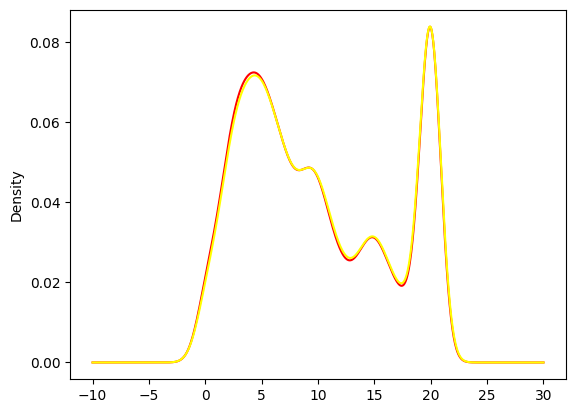

In [94]:
fig =plt.figure()
ax = fig.add_subplot(111)

df['experience'].plot.density(color = 'red')

new_df['experience'].plot.density(color= 'yellow')
plt.show()

# Categorical  
compare ratio before and after applying cca if it same it prove data  is missing at random

In [95]:
temp   = pd.concat([
     # percentage of observations per category, original data
    df['education_level'].value_counts() / len(df),
    
    # percentage of observations per category, cca data
    new_df['education_level'].value_counts() / len(new_df)
],axis=1)

temp.columns = ['orignal' , 'cca']

In [96]:
temp

,orignal,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


In [97]:
temp_e= pd.concat([
     # percentage of observations per category, original data
    df['enrolled_university'].value_counts() / len(df) , 

    # percentage of observations per category, cca data
    new_df['enrolled_university'].value_counts() / len(new_df) 
], axis = 1)

temp_e. columns = ['orignal' , 'cca']

In [98]:
temp_e

,orignal,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079
